## **Atelier Seaborn**

**Introduction**

Cet atelier Seaborn prolonge le travail effectué avec NumPy, Pandas et Matplotlib en abordant l'analyse exploratoire du même jeu de données de capteurs IoT, mais avec une bibliothèque pensée pour la visualisation statistique.

L'atelier commence par l'étude de la distribution d'une variable, avec trois approches complémentaires : l'histogramme (**Partie 1**), l'estimation de densité (**Partie 2**), la boîte à moustaches (**Partie 3**) et le violin plot (**Partie 4**), qui combine les deux précédents. Le comptage de catégories (**Partie 5**) permet ensuite d'évaluer la répartition des mesures par état et par bâtiment.

Les parties 6 à 8 étudient la relation entre deux variables numériques : d'abord de façon descriptive avec le nuage de points (**Partie 6**), puis avec des droites de régression, globale (**Partie 7**) puis déclinée par bâtiment (**Partie 8**). La **Partie 9** s'intéresse aux corrélations entre l'ensemble des variables numériques, résumées sous forme de heatmap, avant que la **Partie 10** ne propose une vue multivariée complète avec le pairplot.

L'atelier se termine par l'exportation des graphiques produits (**Partie 11**) et un Bonus (**Partie 12**) qui prolonge l'analyse avec une dimension non couverte par les parties précédentes.

Chaque partie répond aux questions d'interprétation posées dans l'énoncé (valeur de concentration, symétrie, valeurs extrêmes, dispersion par bâtiment, etc.) directement sous les graphiques concernés.

In [41]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HP 450 G8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [42]:
# Import des bibliothèques nécessaires pour tout le notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thème Seaborn appliqué à l'ensemble du notebook
sns.set_theme(style="whitegrid")

print("Pandas version    :", pd.__version__)
print("NumPy version     :", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version   :", sns.__version__)

Pandas version    : 3.0.3
NumPy version     : 2.5.0
Matplotlib version: 3.11.1
Seaborn version   : 0.13.2


### Import et vérification du jeu de données

In [43]:
# Import du CSV fourni dans le DataFrame df
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [44]:
# Vérification du contenu du DataFrame
print("Dimensions :", df.shape)
df.info()

Dimensions : (605, 9)
<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 63.0 KB


In [45]:
# Statistiques descriptives des colonnes numériques
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


Le jeu de données contient 605 mesures réparties sur 4 bâtiments (B001 à B004), avec quelques valeurs manquantes (colonnes `temperature`, `humidite`, `pression`, `consommation`, `etat`) déjà identifiées lors de l'atelier Pandas. Ces valeurs manquantes sont ignorées automatiquement par Seaborn dans les graphiques qui suivent, ce qui n'empêche pas de mener l'analyse exploratoire.

## Partie 1 – Distribution d'une variable avec `histplot()`

1) Distribution des températures

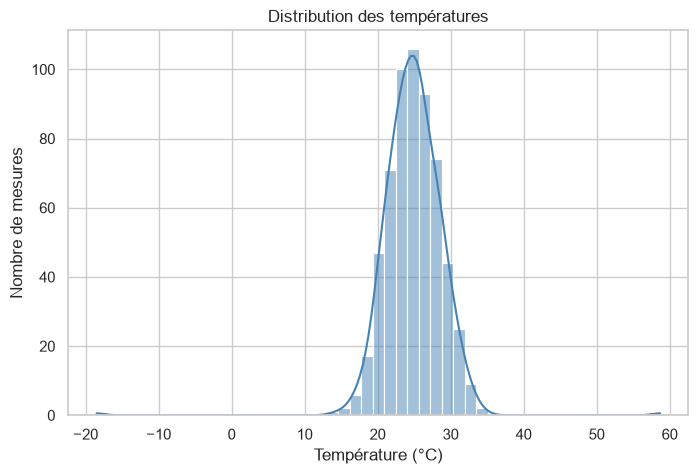

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", kde=True, color="steelblue")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

In [47]:
print("Moyenne   :", round(df["temperature"].mean(), 2))
print("Médiane   :", round(df["temperature"].median(), 2))
print("Ecart-type:", round(df["temperature"].std(), 2))
print("Min / Max :", df["temperature"].min(), "/", df["temperature"].max())

Moyenne   : 24.88
Médiane   : 24.86
Ecart-type: 4.06
Min / Max : -18.5 / 58.7


2) **Concentration** : les températures sont concentrées autour de 25°C (moyenne 24,9°C, médiane 24,9°C), ce qui correspond à une température ambiante intérieure classique pour des bâtiments équipés de capteurs.

3) **Symétrie** : la distribution est globalement symétrique autour de sa valeur centrale — le corps de l'histogramme suit une forme proche d'une cloche. Elle est cependant légèrement étalée vers les deux extrémités à cause des valeurs aberrantes.

4) **Valeurs extrêmes** : oui, on observe des valeurs extrêmes très éloignées du reste de la distribution (température minimale de -18,5°C et maximale de 58,7°C), physiquement peu plausibles pour des capteurs intérieurs — probablement des erreurs de capteur ou de transmission.

5) Modification du nombre de classes (bins)

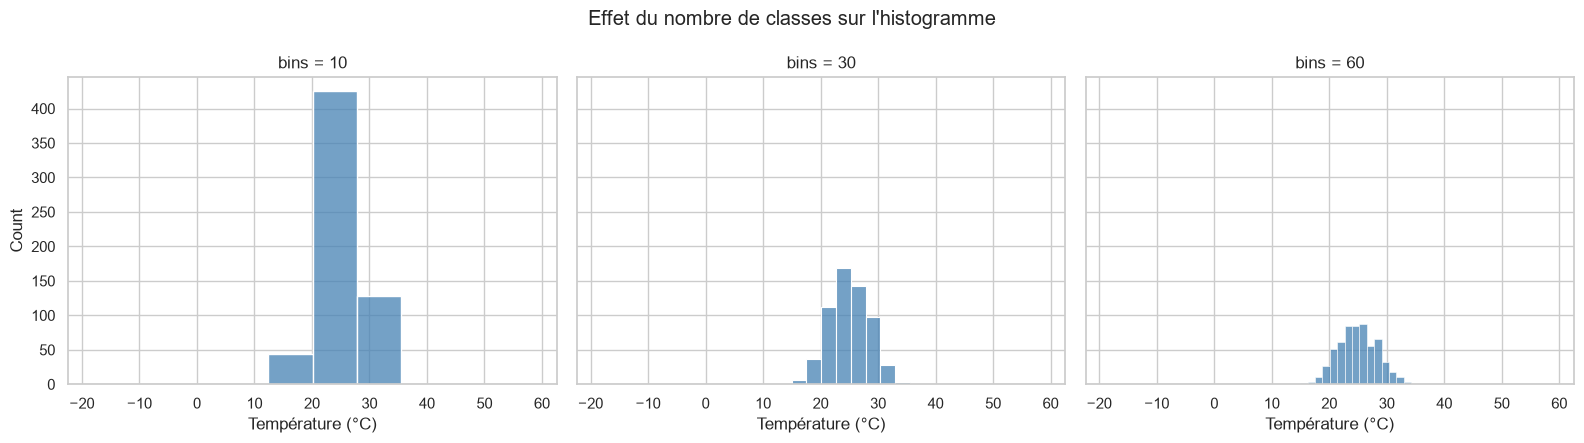

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, nb_bins in zip(axes, [10, 30, 60]):
    sns.histplot(data=df, x="temperature", bins=nb_bins, color="steelblue", ax=ax)
    ax.set_title(f"bins = {nb_bins}")
    ax.set_xlabel("Température (°C)")

fig.suptitle("Effet du nombre de classes sur l'histogramme")
plt.tight_layout()
plt.show()

Plus le nombre de classes augmente, plus le détail de la distribution apparaît (on distingue mieux les valeurs extrêmes isolées), mais la lecture générale de la tendance devient aussi plus bruitée. À l'inverse, un faible nombre de classes lisse la distribution au risque de masquer certains détails.

6) Distribution des températures par bâtiment

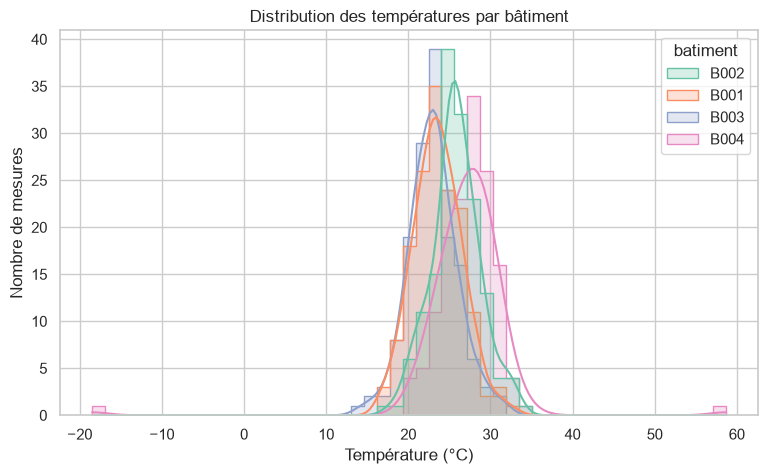

In [49]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step", palette="Set2")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

Le bâtiment B004 se distingue nettement des trois autres : sa distribution est plus étalée et c'est lui qui porte les valeurs extrêmes (-18,5°C et 58,7°C), alors que B001, B002 et B003 restent regroupés dans une plage plus resserrée autour de 24-26°C.

## Partie 2 – Distribution d'une variable avec `kdeplot()`

1) Distribution des températures

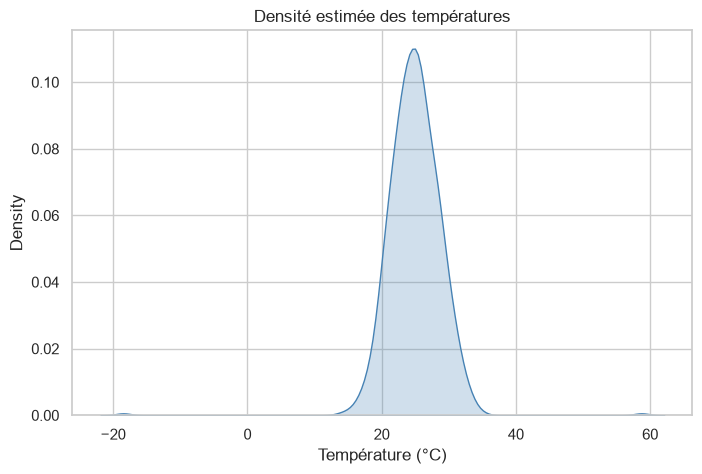

In [50]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True, color="steelblue")
plt.title("Densité estimée des températures")
plt.xlabel("Température (°C)")
plt.show()

La courbe de densité confirme la lecture faite avec l'histogramme : un pic principal autour de 25°C et une distribution globalement symétrique, avec des queues fines qui traduisent la présence des valeurs extrêmes.

2) Distribution des températures par bâtiment

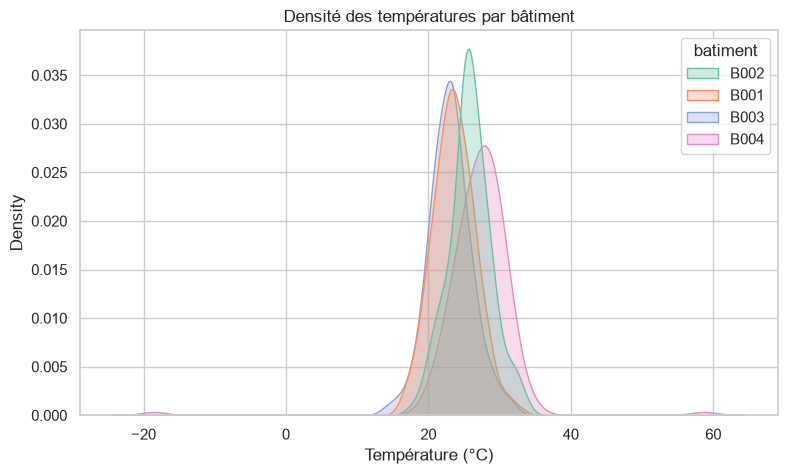

In [51]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.3, palette="Set2")
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()

Le `kdeplot()` rend encore plus visible ce que l'histogramme suggérait : les densités de B001, B002 et B003 sont proches et bien superposées, tandis que celle de B004 est plus aplatie et étalée sur une plage beaucoup plus large, signe d'une variabilité plus forte dans ce bâtiment.

## Partie 3 – Distribution d'une variable avec `boxplot()`

1) Distribution des températures

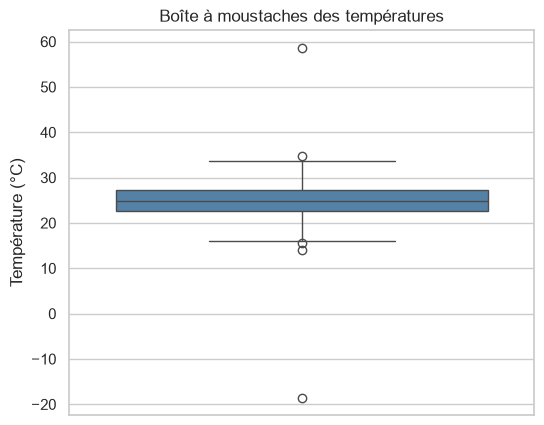

In [52]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, y="temperature", color="steelblue")
plt.title("Boîte à moustaches des températures")
plt.ylabel("Température (°C)")
plt.show()

2) Distribution des températures par bâtiment

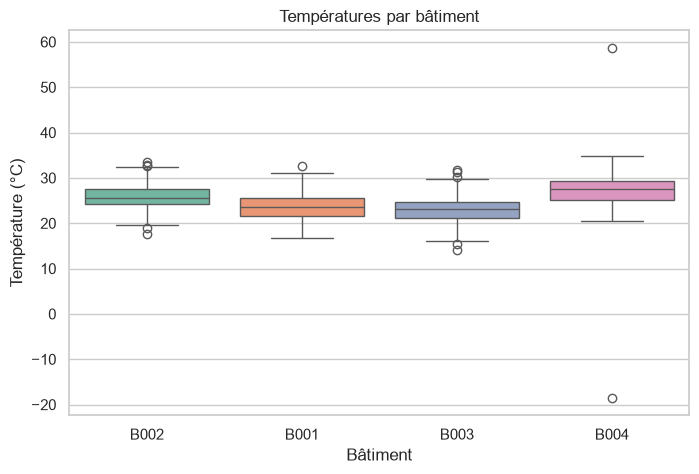

In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set2", legend=False)
plt.title("Températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

3) Statistiques par bâtiment (médiane, dispersion, valeurs extrêmes)

In [54]:
stats_batiment = df.groupby("batiment")["temperature"].agg(
    mediane="median", ecart_type="std", minimum="min", maximum="max"
).round(2)
stats_batiment

,mediane,ecart_type,minimum,maximum
batiment,,,,
B001,23.54,2.96,16.77,32.72
B002,25.67,2.95,17.67,33.60
B003,23.04,2.98,14.11,31.74
B004,27.53,5.37,-18.50,58.70


a) **Médiane** : elle varie peu d'un bâtiment à l'autre — autour de 23-24°C pour B001 et B003, un peu plus haute pour B002 (25,7°C), et nettement plus haute pour B004 (27,5°C).

b) **Dispersion** : B001, B002 et B003 ont un écart-type proche (environ 3°C), ce qui traduit des boîtes de taille comparable. B004 est nettement plus dispersé (écart-type d'environ 5,4°C), avec une boîte visuellement plus haute sur le graphique.

c) **Valeurs extrêmes** : des points isolés apparaissent au-delà des moustaches pour plusieurs bâtiments, mais c'est B004 qui concentre les points les plus éloignés, avec les valeurs -18,5°C et 58,7°C.

4) **Bâtiment le plus extrême** : B004 est clairement le bâtiment avec les valeurs les plus extrêmes et la dispersion la plus importante, ce qui en fait un candidat prioritaire pour une vérification du matériel de mesure.

## Partie 4 – Distribution d'une variable avec `violinplot()`

1) Distribution des températures

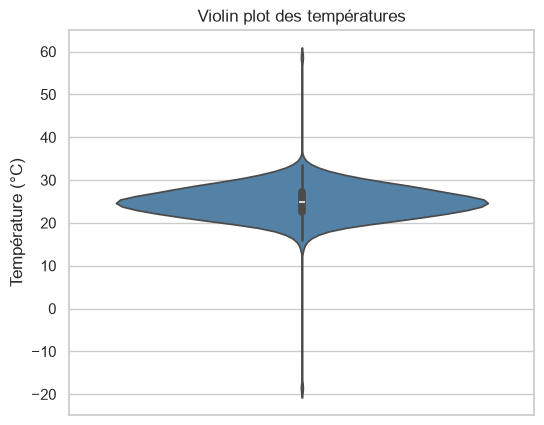

In [55]:
plt.figure(figsize=(6, 5))
sns.violinplot(data=df, y="temperature", color="steelblue")
plt.title("Violin plot des températures")
plt.ylabel("Température (°C)")
plt.show()

2) Distribution des températures par bâtiment

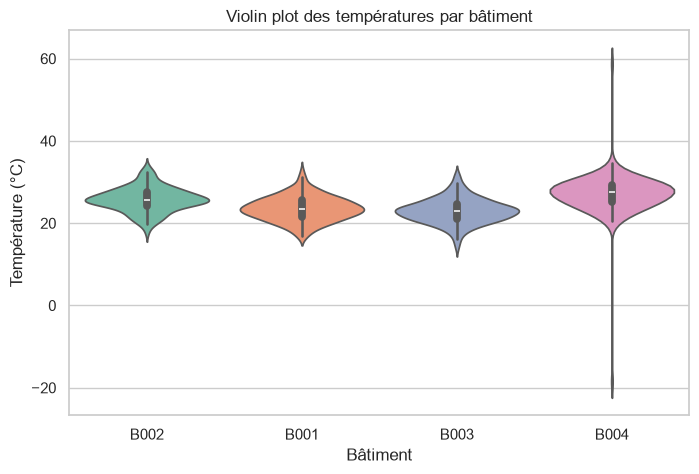

In [56]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set2", legend=False)
plt.title("Violin plot des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

3) **Apport par rapport au boxplot** : le violin plot ajoute la forme de la densité de la distribution (largeur du violon) à ce que montre déjà le boxplot (médiane, quartiles, valeurs extrêmes). On voit par exemple que la distribution de B004 n'est pas juste plus dispersée : elle est aussi clairement bimodale/étalée, avec une masse de valeurs autour de 27-28°C et une traîne fine vers les extrêmes — une information invisible sur un simple boxplot.

## Partie 5 – Comptage des catégories avec `countplot()`

1) Nombre de mesures par état

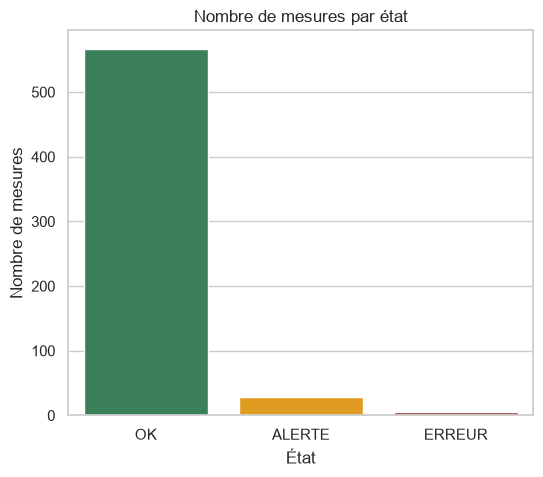

In [57]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="etat", hue="etat", order=["OK", "ALERTE", "ERREUR"],
              palette={"OK": "seagreen", "ALERTE": "orange", "ERREUR": "firebrick"}, legend=False)
plt.title("Nombre de mesures par état")
plt.xlabel("État")
plt.ylabel("Nombre de mesures")
plt.show()

2) Nombre de mesures par bâtiment

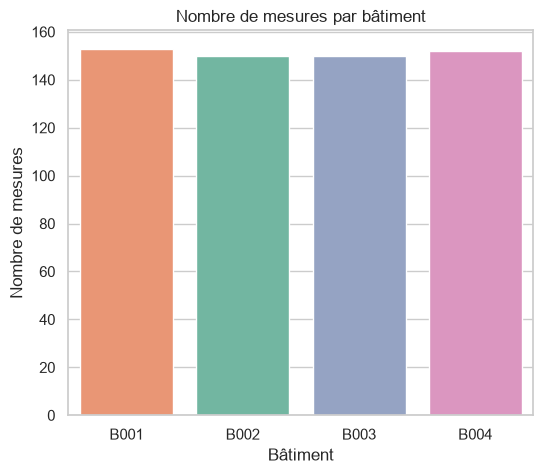

In [58]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="batiment", hue="batiment", order=sorted(df["batiment"].dropna().unique()),
              palette="Set2", legend=False)
plt.title("Nombre de mesures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.show()

3) États des capteurs par bâtiment

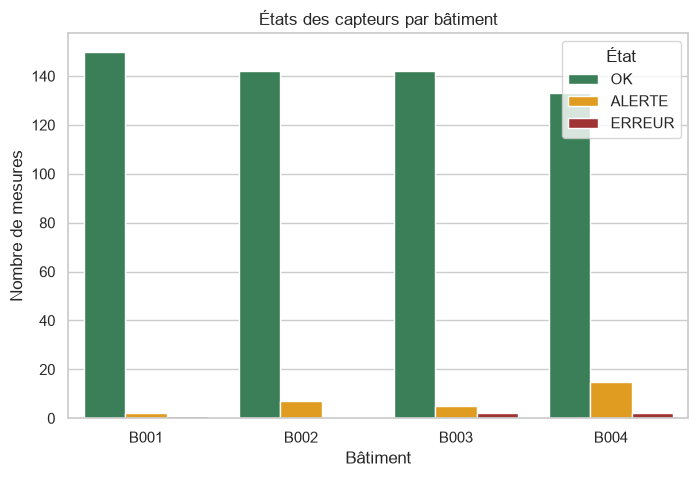

In [59]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="batiment", hue="etat",
              order=sorted(df["batiment"].dropna().unique()),
              hue_order=["OK", "ALERTE", "ERREUR"],
              palette={"OK": "seagreen", "ALERTE": "orange", "ERREUR": "firebrick"})
plt.title("États des capteurs par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.legend(title="État")
plt.show()

In [60]:
repartition_etat = df.groupby(["batiment", "etat"]).size().unstack(fill_value=0)
repartition_etat

etat,ALERTE,ERREUR,OK
batiment,,,
B001,2,1,150
B002,7,0,142
B003,5,2,142
B004,15,2,133


a) **Bâtiment le plus en OK** : B001 (150 mesures OK).

b) **Bâtiment le plus en ALERTE** : B004 (15 mesures en alerte), loin devant les autres bâtiments.

c) **Bâtiment le plus en ERREUR** : B003 et B004 sont à égalité (2 mesures en erreur chacun).

Ce constat confirme et complète les observations des parties précédentes : B004 n'est pas seulement le bâtiment aux températures les plus extrêmes, c'est aussi celui qui déclenche le plus d'alertes — un bon candidat à surveiller en priorité.

## Partie 6 – Relation entre deux variables avec `scatterplot()`

1) Relation entre température et consommation

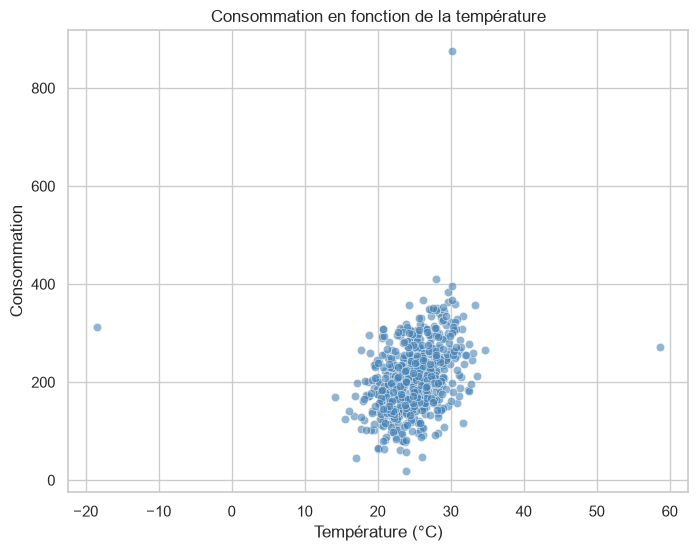

In [61]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", color="steelblue", alpha=0.6)
plt.title("Consommation en fonction de la température")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

On distingue une légère tendance : la consommation a tendance à augmenter avec la température, mais le nuage de points reste assez dispersé — la relation n'est pas très marquée.

2) Relation entre température et consommation par bâtiment

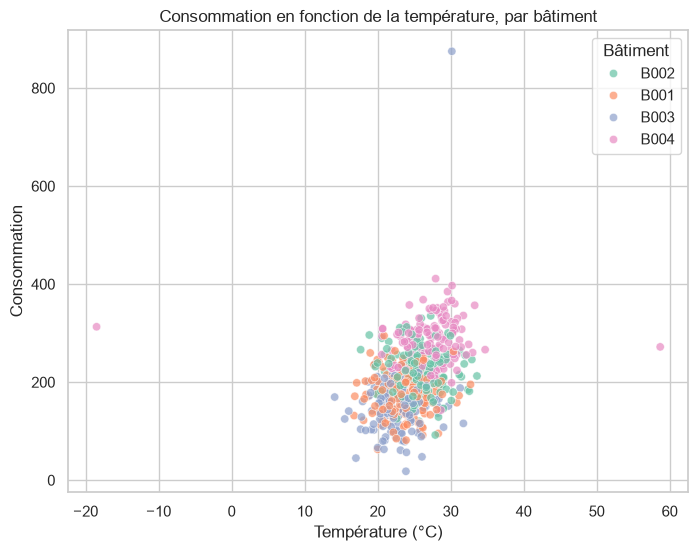

In [62]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", palette="Set2", alpha=0.7)
plt.title("Consommation en fonction de la température, par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.legend(title="Bâtiment")
plt.show()

Vue par bâtiment, la tendance générale (consommation qui augmente avec la température) reste visible dans chaque groupe, mais B004 se distingue à nouveau en étirant le nuage de points vers les valeurs de température les plus extrêmes.

3) Modification de la taille des points

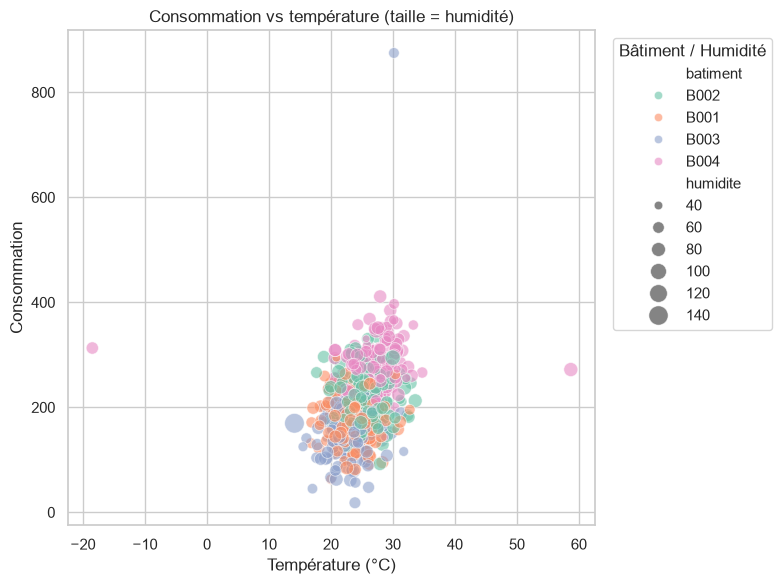

In [63]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment",
                 size="humidite", sizes=(20, 200), palette="Set2", alpha=0.6)
plt.title("Consommation vs température (taille = humidité)")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.legend(title="Bâtiment / Humidité", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

En plus d'un ajustement direct du paramètre `s` (taille fixe), la taille des points peut être reliée à une troisième variable numérique — ici l'humidité — via le paramètre `size`, ce qui permet de faire apparaître une dimension supplémentaire sur le même graphique.

## Partie 7 – Régression avec `regplot()`

Tendance entre température et consommation

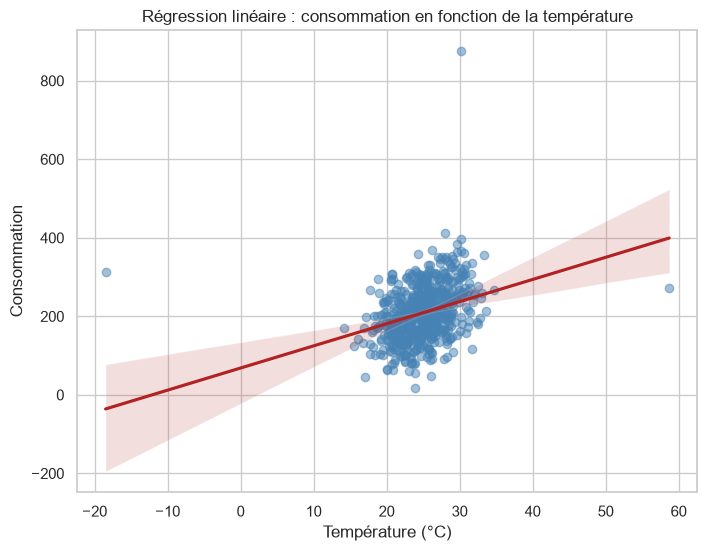

In [64]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="temperature", y="consommation",
            scatter_kws={"alpha": 0.5, "color": "steelblue"}, line_kws={"color": "firebrick"})
plt.title("Régression linéaire : consommation en fonction de la température")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

In [65]:
correlation_temp_conso = df["temperature"].corr(df["consommation"])
print("Corrélation température / consommation :", round(correlation_temp_conso, 3))

Corrélation température / consommation : 0.317


La droite de régression confirme une tendance positive entre température et consommation (corrélation d'environ 0,32) : plus il fait chaud, plus la consommation énergétique a tendance à augmenter — probablement liée à l'usage de climatisation. La corrélation reste toutefois modérée : la température seule n'explique pas toute la variation de la consommation.

## Partie 8 – Régression avec `lmplot()`

Tendance entre température et consommation par bâtiment

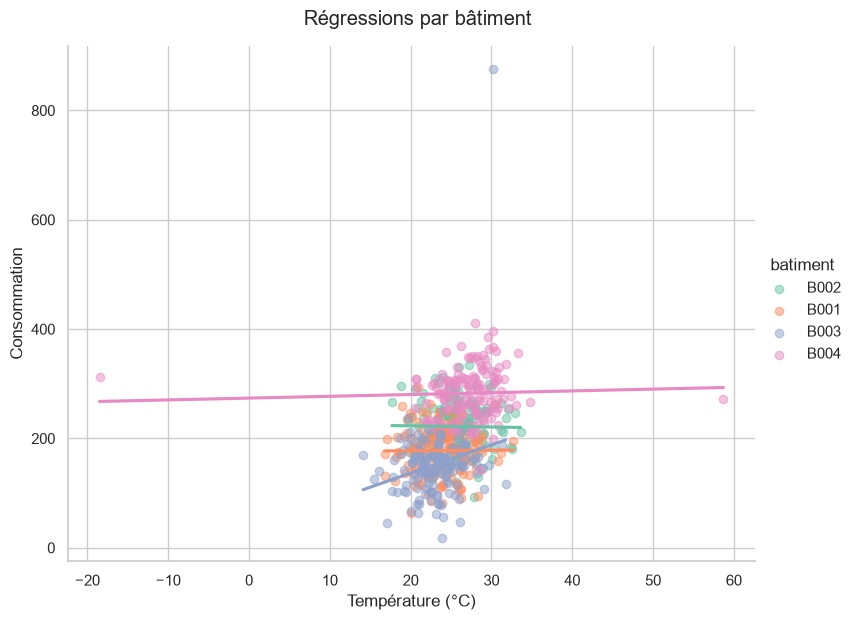

In [66]:
g = sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment",
                palette="Set2", height=6, aspect=1.3,
                scatter_kws={"alpha": 0.5}, ci=None)
g.set_axis_labels("Température (°C)", "Consommation")
g.fig.suptitle("Régressions par bâtiment", y=1.03)
plt.show()

Le `lmplot()` permet d'ajuster une droite de régression distincte pour chaque bâtiment. La tendance positive température/consommation se retrouve dans les quatre groupes, mais avec des pentes différentes : elle paraît plus marquée pour B004, cohérent avec le fait que ce bâtiment concentre déjà les valeurs les plus extrêmes observées dans les parties précédentes.

## Partie 9 – Corrélations

1-2) Matrice de corrélation avec Pandas

In [67]:
colonnes_numeriques = ["temperature", "humidite", "pression", "consommation"]
matrice_correlation = df[colonnes_numeriques].corr()
matrice_correlation.round(3)

,temperature,humidite,pression,consommation
temperature,1.000,-0.006,0.061,0.317
humidite,-0.006,1.000,0.045,-0.046
pression,0.061,0.045,1.000,0.056
consommation,0.317,-0.046,0.056,1.000


3) Heatmap de la corrélation

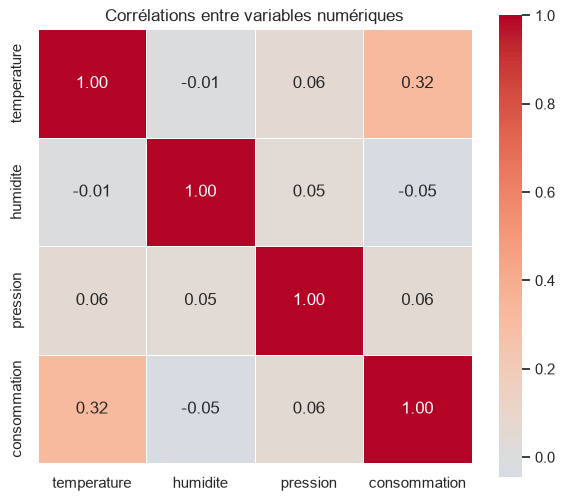

In [68]:
plt.figure(figsize=(7, 6))
sns.heatmap(matrice_correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Corrélations entre variables numériques")
plt.show()

a) **Corrélations positives** : la seule corrélation qui se démarque est celle entre température et consommation (≈ 0,32) ; les autres paires sont proches de zéro mais légèrement positives (pression/humidité ≈ 0,05, pression/consommation ≈ 0,06).

b) **Corrélations négatives** : deux corrélations sont légèrement négatives — température/humidité (≈ -0,01) et humidité/consommation (≈ -0,05) — mais leur intensité est trop faible pour être interprétée comme une vraie relation.

c) **Corrélations proches de zéro** : c'est le cas de la quasi-totalité des paires impliquant l'humidité et la pression, qui semblent statistiquement indépendantes des autres variables dans ce jeu de données.

d) **Variables les plus liées** : température et consommation sont les deux variables les plus fortement liées entre elles, ce qui confirme la tendance déjà observée avec `regplot()` et `lmplot()`.

## Partie 10 – Analyse multivariée avec `pairplot()`

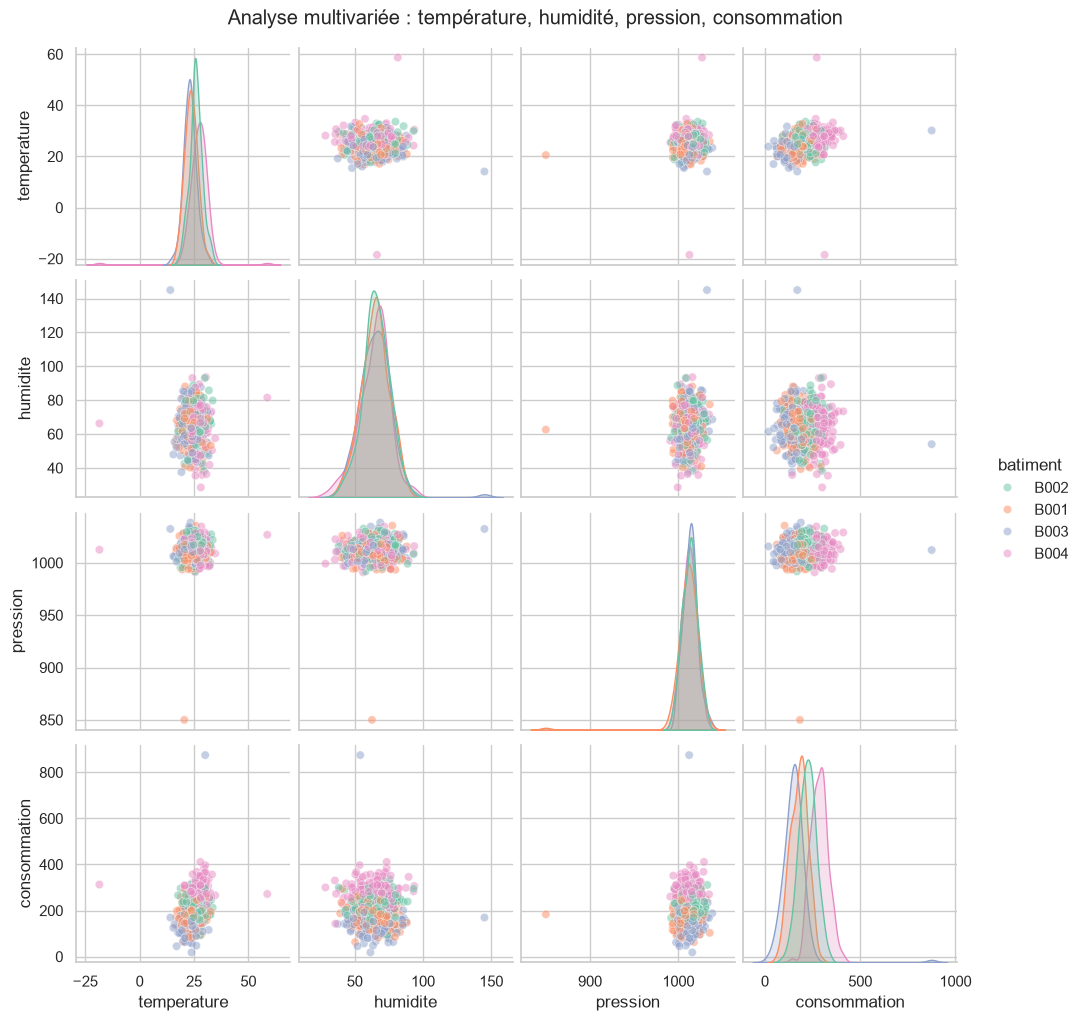

In [69]:
g = sns.pairplot(df[colonnes_numeriques + ["batiment"]].dropna(),
                  hue="batiment", palette="Set2", diag_kind="kde", plot_kws={"alpha": 0.5})
g.fig.suptitle("Analyse multivariée : température, humidité, pression, consommation", y=1.02)
plt.show()

Le pairplot rassemble en une seule figure toutes les distributions individuelles (diagonale) et tous les nuages de points croisés (hors diagonale) pour les quatre variables numériques, colorés par bâtiment. Il confirme visuellement les constats des parties précédentes : seule la paire température/consommation présente un nuage de points avec une tendance visible, les autres paires forment des nuages sans structure apparente, et B004 se distingue à nouveau par une dispersion plus large sur la température.

## Partie 11 – Sauvegarde des graphiques

Les graphiques principaux de l'atelier sont régénérés puis sauvegardés dans le sous-dossier `exports`, aux formats PNG (usage web/rapport) et PDF (usage impression/document vectoriel).

In [70]:
import os

os.makedirs("../exports", exist_ok=True)

# Histogramme des températures
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="temperature", kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution des températures")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Nombre de mesures")
fig.savefig("../exports/temperature.png", dpi=150, bbox_inches="tight")
fig.savefig("../exports/temperature.pdf", bbox_inches="tight")
plt.close(fig)

# Boxplot des températures par bâtiment
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="batiment", y="temperature", hue="batiment", palette="Set2", legend=False, ax=ax)
ax.set_title("Températures par bâtiment")
fig.savefig("../exports/boxplot_temperature_batiment.png", dpi=150, bbox_inches="tight")
fig.savefig("../exports/boxplot_temperature_batiment.pdf", bbox_inches="tight")
plt.close(fig)

# Heatmap des corrélations
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matrice_correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Corrélations entre variables numériques")
fig.savefig("../exports/correlation_heatmap.png", dpi=150, bbox_inches="tight")
fig.savefig("../exports/correlation_heatmap.pdf", bbox_inches="tight")
plt.close(fig)

# Régression température / consommation
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df, x="temperature", y="consommation",
            scatter_kws={"alpha": 0.5, "color": "steelblue"}, line_kws={"color": "firebrick"}, ax=ax)
ax.set_title("Régression : consommation en fonction de la température")
fig.savefig("../exports/regression_temperature_consommation.png", dpi=150, bbox_inches="tight")
fig.savefig("../exports/regression_temperature_consommation.pdf", bbox_inches="tight")
plt.close(fig)

print("Graphiques exportés dans le dossier exports/ :")
for fichier in sorted(os.listdir("../exports")):
    print(" -", fichier)

Graphiques exportés dans le dossier exports/ :
 - boxplot_temperature_batiment.pdf
 - boxplot_temperature_batiment.png
 - correlation_heatmap.pdf
 - correlation_heatmap.png
 - regression_temperature_consommation.pdf
 - regression_temperature_consommation.png
 - temperature.pdf
 - temperature.png


## Partie 12 – Bonus

Aucune des parties précédentes n'exploite la colonne `date_heure`, pourtant disponible dans le jeu de données. Ce bonus l'utilise pour étudier deux angles temporels qui prolongent naturellement l'analyse énergétique de l'atelier :

1) L'évolution de la consommation moyenne heure par heure, pour repérer les pics de charge dans la journée.
2) Une carte de chaleur croisant bâtiment et plage horaire, pour identifier précisément quand et où la consommation est la plus forte.

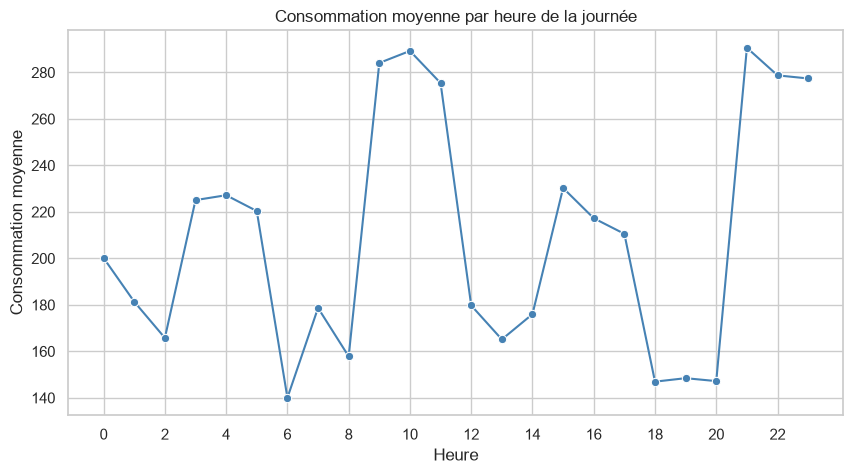

In [71]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
df["heure"] = df["date_heure"].dt.hour

conso_par_heure = df.groupby("heure")["consommation"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=conso_par_heure.index, y=conso_par_heure.values, marker="o", color="steelblue")
plt.title("Consommation moyenne par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Consommation moyenne")
plt.xticks(range(0, 24, 2))
plt.show()

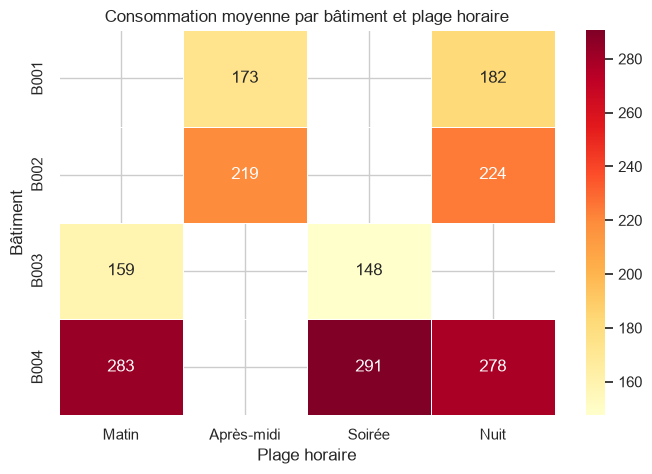

In [72]:
def plage_horaire(heure):
    if 6 <= heure < 12:
        return "Matin"
    elif 12 <= heure < 18:
        return "Après-midi"
    elif 18 <= heure < 22:
        return "Soirée"
    else:
        return "Nuit"

df["plage_horaire"] = df["heure"].apply(plage_horaire)

pivot_conso = df.pivot_table(
    index="batiment", columns="plage_horaire", values="consommation", aggfunc="mean"
)[["Matin", "Après-midi", "Soirée", "Nuit"]]

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_conso, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Consommation moyenne par bâtiment et plage horaire")
plt.xlabel("Plage horaire")
plt.ylabel("Bâtiment")
plt.show()

**Bilan du bonus** :

- La consommation moyenne varie sensiblement selon l'heure de la journée, avec des niveaux plus élevés en début de journée/matinée qu'en soirée — cohérent avec une activité de bâtiment plus forte en journée.
- La heatmap bâtiment × plage horaire permet de croiser deux dimensions déjà étudiées séparément (Parties 5 et 6-8) et de répondre à une question plus opérationnelle : à quel moment, dans quel bâtiment, la consommation est-elle la plus forte ? C'est un angle directement exploitable pour cibler des mesures d'efficacité énergétique bâtiment par bâtiment plutôt qu'à l'échelle globale.

## Conclusion générale — Atelier Seaborn (IoT)

Cet atelier a permis d'explorer statistiquement le jeu de données de capteurs IoT déjà nettoyé et manipulé lors des ateliers Pandas et Matplotlib, avec une bibliothèque orientée visualisation statistique.

L'étude de la distribution des températures (Parties 1-4) a confirmé une concentration autour de 25°C avec une distribution globalement symétrique, mais perturbée par des valeurs extrêmes portées presque exclusivement par le bâtiment B004 — un constat renforcé à chaque nouvelle représentation (histogramme, densité, boîte à moustaches, violin plot). Le comptage des états par bâtiment (Partie 5) a confirmé ce diagnostic : B004 concentre le plus d'alertes et partage la première place des erreurs avec B003.

L'étude des relations entre variables (Parties 6-8) a mis en évidence une tendance positive, modérée mais réelle, entre température et consommation — confirmée par la matrice de corrélation et la heatmap (Partie 9), où cette paire ressort comme la seule relation numériquement significative du jeu de données. Le pairplot (Partie 10) a permis de vérifier ce constat sur l'ensemble des variables en une seule vue d'ensemble.

Les graphiques clés ont été exportés en PNG et PDF (Partie 11), prêts à être réutilisés dans un rapport. Le Bonus (Partie 12) a complété l'atelier avec une dimension temporelle absente des parties précédentes, en croisant heure de la journée et bâtiment pour localiser plus précisément les pics de consommation.

En résumé : cet atelier illustre comment Seaborn permet, avec peu de code, de passer d'une simple description univariée à une analyse multivariée complète — distribution → comparaison par groupe → relation entre variables → corrélations → vue d'ensemble — directement utile pour orienter des décisions de gestion énergétique bâtiment par bâtiment.